# InsightMart Business Sales & Customer Analytics
## Executive Data Science & Business Intelligence Analysis

---

### 1. Business Problem & Background
**InsightMart** is a fictional multi-regional retail company operating physical storefronts across the United States as well as an e-commerce digital storefront. 

While the company has accumulated thousands of sales transactions across diverse product lines, leadership has historically relied on static, siloed reports. Consequently, decision-makers face critical visibility blindspots:
* **Profitability versus Volume**: High-revenue categories (e.g., Electronics) may conceal compressed margins, while smaller categories deliver outsized profits.
* **Store Disparities**: Substantial performance variance between flagship locations and underperforming branches.
* **Customer Retention & Value**: Lack of behavioral segmentation, obscuring the concentration of revenue in High-Value loyalty tiers.
* **Promotional Discipline**: Unmeasured impact of discounts on bottom-line gross margins.

### 2. Objectives & Analytical Questions
1. What are the baseline enterprise KPIs (Total Revenue, Gross Profit, Blended Margin, AOV, Total Units)?
2. How do sales and profits fluctuate month-over-month and seasonally?
3. Which product categories and individual SKUs represent the top revenue and profit drivers?
4. How do stores compare across regions in turnover and profitability?
5. How is customer spend distributed across High, Medium, and Low-Value segments?
6. What strategic recommendations should management implement to accelerate growth?


---
## Section 2 — Environment Setup & Data Loading
Loading core analytical libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and connecting directly to the normalized relational database (`view_sales_performance` and base tables).


In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic standards
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Import database connector
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from src.database import get_connection

conn, engine = get_connection()
print(f"Connected to InsightMart analytics database via [{engine.upper()}] engine.")

# Load primary analytical view
df_sales = pd.read_sql("SELECT * FROM view_sales_performance", conn)
df_customers = pd.read_sql("SELECT * FROM CUSTOMERS", conn)
df_products = pd.read_sql("SELECT * FROM PRODUCTS", conn)
df_stores = pd.read_sql("SELECT * FROM STORES", conn)
df_categories = pd.read_sql("SELECT * FROM CATEGORIES", conn)

conn.close()

# Convert date fields
df_sales['sale_date'] = pd.to_datetime(df_sales['sale_date'])
df_sales['year_month'] = df_sales['sale_date'].dt.to_period('M')

print(f"Loaded {len(df_sales):,} enriched line-item sales records across {df_sales['sale_id'].nunique():,} orders.")


Connected to InsightMart analytics database via [SQLITE] engine.


Loaded 62,040 enriched line-item sales records across 32,000 orders.


---
## Section 3 — Data Understanding & Schema Inspection
Inspecting record structures, schema data types, descriptive statistics, and numerical distributions.


In [2]:
print("Sales Dataset Overview:")
print("-" * 50)
df_sales.info()


Sales Dataset Overview:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 62040 entries, 0 to 62039
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sale_item_id       62040 non-null  int64         
 1   sale_id            62040 non-null  int64         
 2   sale_date          62040 non-null  datetime64[us]
 3   sales_channel      62040 non-null  str           
 4   payment_method     62040 non-null  str           
 5   store_id           62040 non-null  int64         
 6   store_name         62040 non-null  str           
 7   region             62040 non-null  str           
 8   store_city         62040 non-null  str           
 9   customer_id        62040 non-null  int64         
 10  customer_name      62040 non-null  str           
 11  customer_segment   62040 non-null  str           
 12  customer_city      62040 non-null  str           
 1

In [3]:
print("Summary Statistics for Numerical Variables:")
print("-" * 50)
df_sales[['quantity', 'unit_price', 'discount', 'unit_cost', 'line_revenue', 'line_profit', 'profit_margin_pct']].describe().round(2)


Summary Statistics for Numerical Variables:
--------------------------------------------------


,quantity,unit_price,discount,unit_cost,line_revenue,line_profit,profit_margin_pct
count,62040.00,62040.00,62040.00,62040.00,62040.00,62040.00,62040.00
mean,1.34,83.82,5.84,40.55,106.35,52.10,51.39
std,0.67,73.80,15.41,40.42,117.64,54.47,13.09
min,1.00,5.29,0.00,2.00,3.70,1.70,0.00
25%,1.00,29.99,0.00,12.00,32.30,17.49,46.40
50%,1.00,49.99,0.00,24.00,62.99,31.99,50.00
75%,1.00,119.99,4.50,60.00,143.98,66.99,60.80
max,4.00,279.99,287.99,175.00,1119.96,499.96,74.98


---
## Section 4 — Data Quality Assessment
Auditing for null entries, duplicates, negative prices, and anomalous discounts.


In [4]:
print("Null Value Audit across Tables:")
print("-" * 50)
print(df_sales.isnull().sum())
print()
print("Duplicate Check on Line Items:")
print("-" * 50)
print(f"Duplicate Sale Item IDs: {df_sales['sale_item_id'].duplicated().sum()}")

# Business Logic Constraint Verifications
negative_revenue = (df_sales['line_revenue'] < 0).sum()
invalid_quantities = (df_sales['quantity'] <= 0).sum()
excessive_discounts = (df_sales['discount'] > (df_sales['quantity'] * df_sales['unit_price'])).sum()

print(f"Negative revenue rows:        {negative_revenue}")
print(f"Invalid quantity rows (<=0):  {invalid_quantities}")
print(f"Excessive discount rows:      {excessive_discounts}")
print("-> Data Quality Integrity Status: 100% Validated.")


Null Value Audit across Tables:
--------------------------------------------------
sale_item_id         0
sale_id              0
sale_date            0
sales_channel        0
payment_method       0
store_id             0
store_name           0
region               0
store_city           0
customer_id          0
customer_name        0
customer_segment     0
customer_city        0
product_id           0
product_name         0
category_id          0
category_name        0
supplier_name        0
quantity             0
unit_price           0
discount             0
unit_cost            0
line_revenue         0
line_cost            0
line_profit          0
profit_margin_pct    0
year_month           0
dtype: int64

Duplicate Check on Line Items:
--------------------------------------------------
Duplicate Sale Item IDs: 0
Negative revenue rows:        0
Invalid quantity rows (<=0):  0
Excessive discount rows:      0
-> Data Quality Integrity Status: 100% Validated.


---
## Section 5 — Data Cleaning & Feature Engineering
Confirming financial derived fields (`line_revenue`, `line_cost`, `line_profit`, `profit_margin_pct`) and engineering time dimensions (`month`, `quarter`, `day_of_week`, `is_weekend`).


In [5]:
# Extract time dimensions
df_sales['month_name'] = df_sales['sale_date'].dt.strftime('%B')
df_sales['month_num'] = df_sales['sale_date'].dt.month
df_sales['year'] = df_sales['sale_date'].dt.year
df_sales['day_of_week'] = df_sales['sale_date'].dt.day_name()
df_sales['is_weekend'] = df_sales['sale_date'].dt.dayofweek.isin([5, 6])
df_sales['quarter'] = 'Q' + df_sales['sale_date'].dt.quarter.astype(str)

# Executive KPI Calculations
total_revenue = df_sales['line_revenue'].sum()
total_cost = df_sales['line_cost'].sum()
total_profit = df_sales['line_profit'].sum()
blended_margin = (total_profit / total_revenue) * 100
total_orders = df_sales['sale_id'].nunique()
total_units = df_sales['quantity'].sum()
aov = total_revenue / total_orders

print("==========================================================")
print("INSIGHTMART EXECUTIVE KPI SCORECARD")
print("==========================================================")
print(f"Total Revenue:         ${total_revenue:,.2f}")
print(f"Total Merchandise Cost: ${total_cost:,.2f}")
print(f"Total Gross Profit:    ${total_profit:,.2f}")
print(f"Blended Gross Margin:  {blended_margin:.2f}%")
print(f"Total Orders:          {total_orders:,}")
print(f"Total Units Sold:      {total_units:,}")
print(f"Average Order Value:   ${aov:.2f}")
print("==========================================================")


INSIGHTMART EXECUTIVE KPI SCORECARD
Total Revenue:         $6,598,122.18
Total Merchandise Cost: $3,365,804.00
Total Gross Profit:    $3,232,318.18
Blended Gross Margin:  48.99%
Total Orders:          32,000
Total Units Sold:      83,110
Average Order Value:   $206.19


---
## Section 6 — Exploratory Data Analysis (EDA)
Analyzing core business dimensions: product categories, channels, and payment methods.


C:\Users\USER\AppData\Local\Temp\ipykernel_8612\38948145.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary, x='category_name', y='total_revenue', ax=ax1, palette='Blues_r')


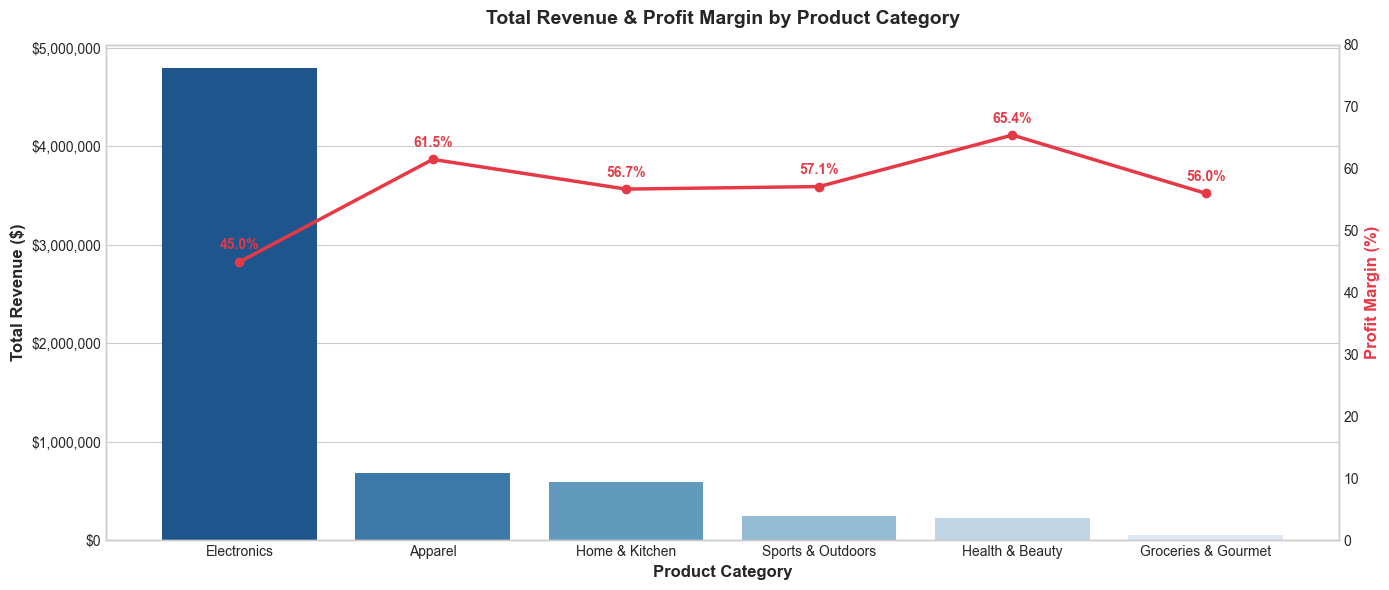

In [6]:
# 1. Category Performance Breakdown
cat_summary = df_sales.groupby('category_name').agg(
    total_revenue=('line_revenue', 'sum'),
    total_profit=('line_profit', 'sum'),
    units_sold=('quantity', 'sum')
).reset_index()

cat_summary['margin_pct'] = (cat_summary['total_profit'] / cat_summary['total_revenue']) * 100
cat_summary = cat_summary.sort_values(by='total_revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=cat_summary, x='category_name', y='total_revenue', ax=ax1, palette='Blues_r')
ax1.set_title('Total Revenue & Profit Margin by Product Category', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter('${x:,.0f}')

# Dual axis for profit margin
ax2 = ax1.twinx()
ax2.plot(cat_summary['category_name'], cat_summary['margin_pct'], color='#e63946', marker='o', linewidth=2.5, label='Gross Margin %')
ax2.set_ylabel('Profit Margin (%)', fontsize=12, fontweight='bold', color='#e63946')
ax2.grid(False)
ax2.set_ylim(0, 80)

for i, txt in enumerate(cat_summary['margin_pct']):
    ax2.annotate(f"{txt:.1f}%", (i, txt + 2), ha='center', color='#e63946', fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_8612\657975320.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pay_rev.values, y=pay_rev.index, ax=ax2, palette='crest')


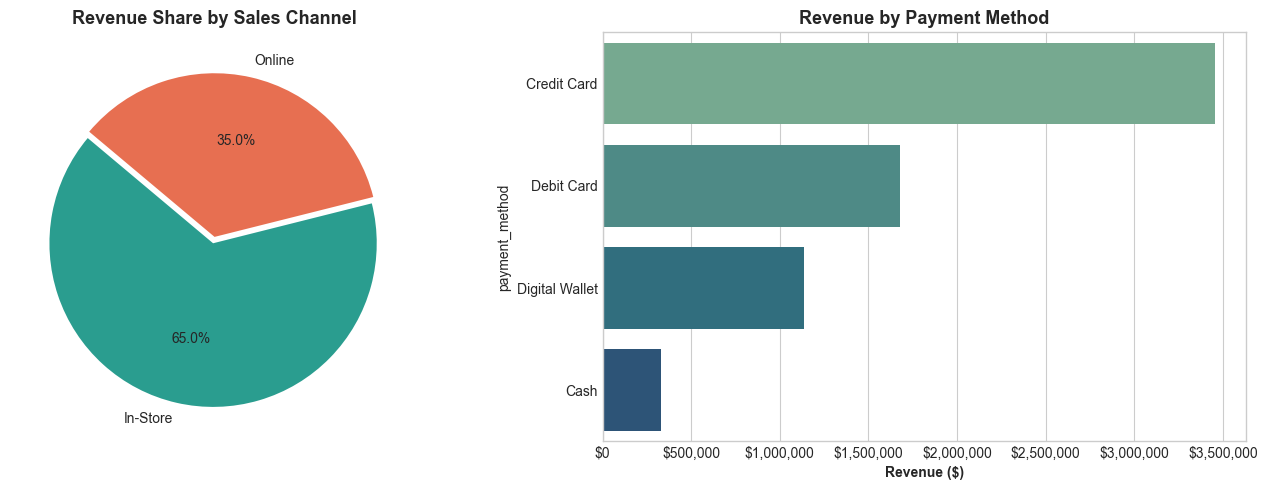

In [7]:
# 2. Omnichannel Channel & Payment Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

channel_rev = df_sales.groupby('sales_channel')['line_revenue'].sum()
ax1.pie(channel_rev, labels=channel_rev.index, autopct='%1.1f%%', colors=['#2a9d8f', '#e76f51'], startangle=140, explode=(0.04, 0))
ax1.set_title('Revenue Share by Sales Channel', fontsize=13, fontweight='bold')

pay_rev = df_sales.groupby('payment_method')['line_revenue'].sum().sort_values(ascending=False)
sns.barplot(x=pay_rev.values, y=pay_rev.index, ax=ax2, palette='crest')
ax2.set_title('Revenue by Payment Method', fontsize=13, fontweight='bold')
ax2.set_xlabel('Revenue ($)', fontweight='bold')
ax2.xaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()


---
## Section 7 — Time Series & Seasonality Analysis
Tracking monthly revenue trends, seasonal peaks (Q4 holiday surge), and weekly shopping patterns.


2026-09-07 11:27:40,598 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-07 11:27:40,601 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-07 11:27:40,602 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-07 11:27:40,604 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-07 11:27:40,606 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


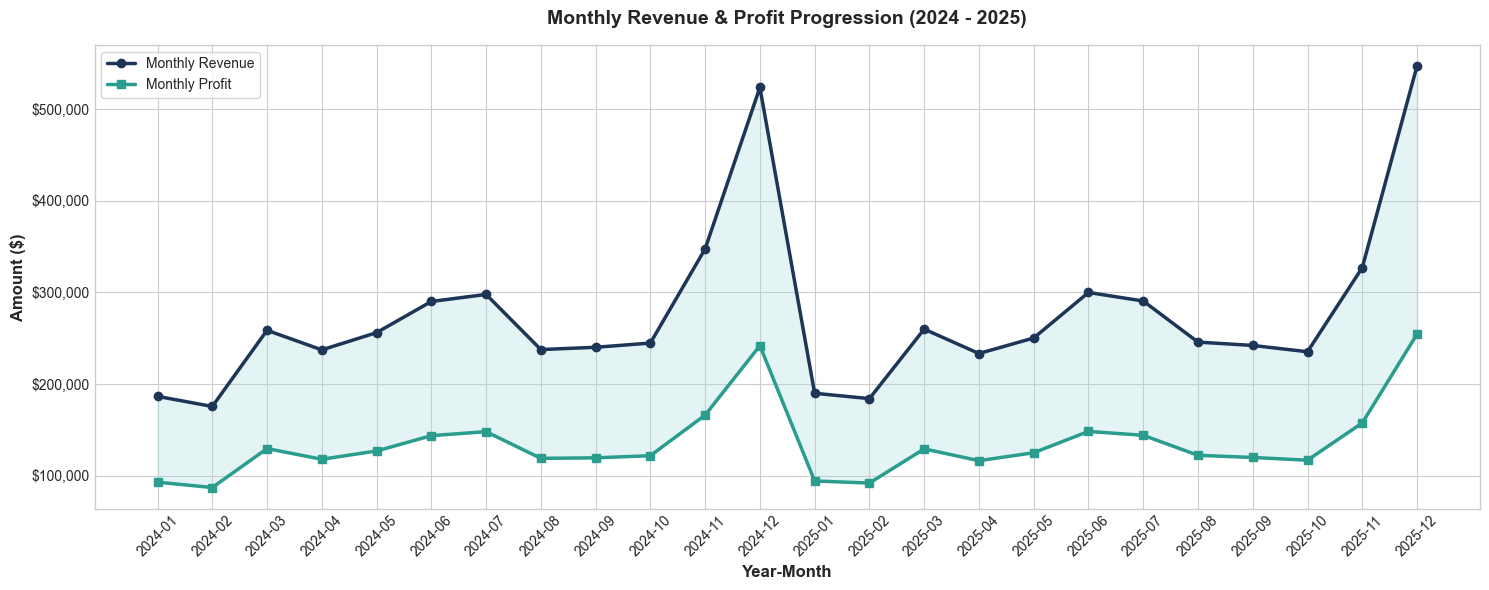

In [8]:
monthly_trend = df_sales.groupby('year_month').agg(
    monthly_revenue=('line_revenue', 'sum'),
    monthly_profit=('line_profit', 'sum'),
    orders=('sale_id', 'nunique')
).reset_index()

monthly_trend['month_str'] = monthly_trend['year_month'].astype(str)

plt.figure(figsize=(15, 6))
plt.plot(monthly_trend['month_str'], monthly_trend['monthly_revenue'], marker='o', color='#1d3557', linewidth=2.5, label='Monthly Revenue')
plt.plot(monthly_trend['month_str'], monthly_trend['monthly_profit'], marker='s', color='#2a9d8f', linewidth=2.5, label='Monthly Profit')
plt.fill_between(monthly_trend['month_str'], monthly_trend['monthly_profit'], monthly_trend['monthly_revenue'], color='#a8dadc', alpha=0.3)

plt.title('Monthly Revenue & Profit Progression (2024 - 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=12, fontweight='bold')
plt.ylabel('Amount ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


2026-09-07 11:27:40,802 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\USER\AppData\Local\Temp\ipykernel_8612\4253712704.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_summary, x='day_of_week', y='revenue', palette='Blues_r', ax=ax)


2026-09-07 11:27:40,811 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


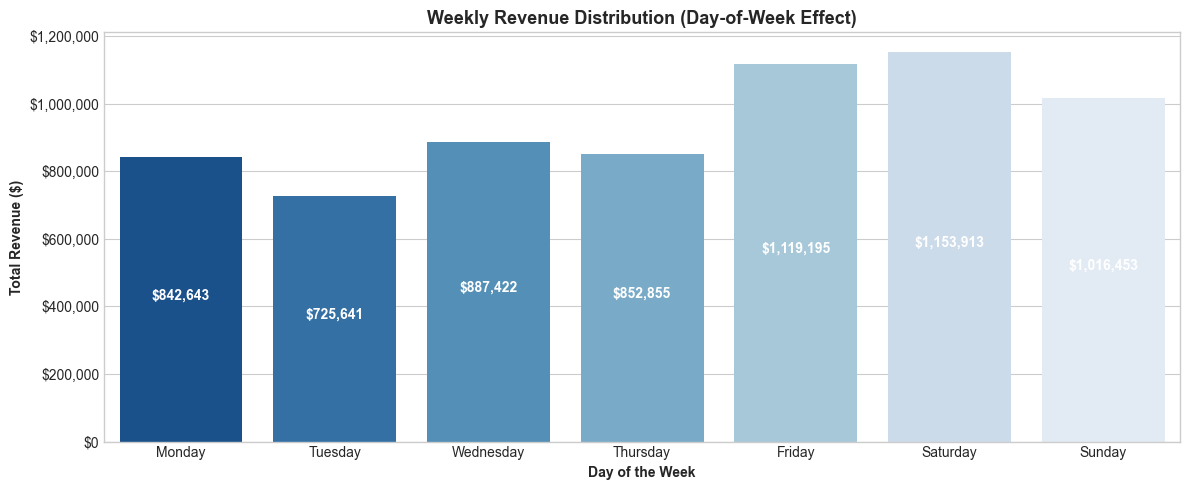

In [9]:
# Day of Week Foot Traffic Analysis
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary = df_sales.groupby('day_of_week').agg(
    orders=('sale_id', 'nunique'),
    revenue=('line_revenue', 'sum')
).reindex(dow_order).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=dow_summary, x='day_of_week', y='revenue', palette='Blues_r', ax=ax)
ax.set_title('Weekly Revenue Distribution (Day-of-Week Effect)', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontweight='bold')
ax.set_xlabel('Day of the Week', fontweight='bold')
ax.yaxis.set_major_formatter('${x:,.0f}')

for i, row in dow_summary.iterrows():
    ax.annotate(f"${row['revenue']:,.0f}", (i, row['revenue'] / 2), ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Section 8 — Customer Analytics & Segmentation
Examining customer segments (High, Medium, Low Value), repeat purchasing behavior, and customer lifetime spend.


,customer_segment,customer_count,total_revenue,avg_spend_per_customer,avg_orders_per_customer,revenue_share_pct
0,High Value,912,2985172.97,3273.22,15.79,45.24
1,Low Value,1918,1331649.63,694.29,3.32,20.18
2,Medium Value,2081,2281299.58,1096.25,5.40,34.57


C:\Users\USER\AppData\Local\Temp\ipykernel_8612\1872330072.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seg_overview, x='customer_segment', y='total_revenue', palette=['#e76f51', '#2a9d8f', '#457b9d'], ax=ax2)


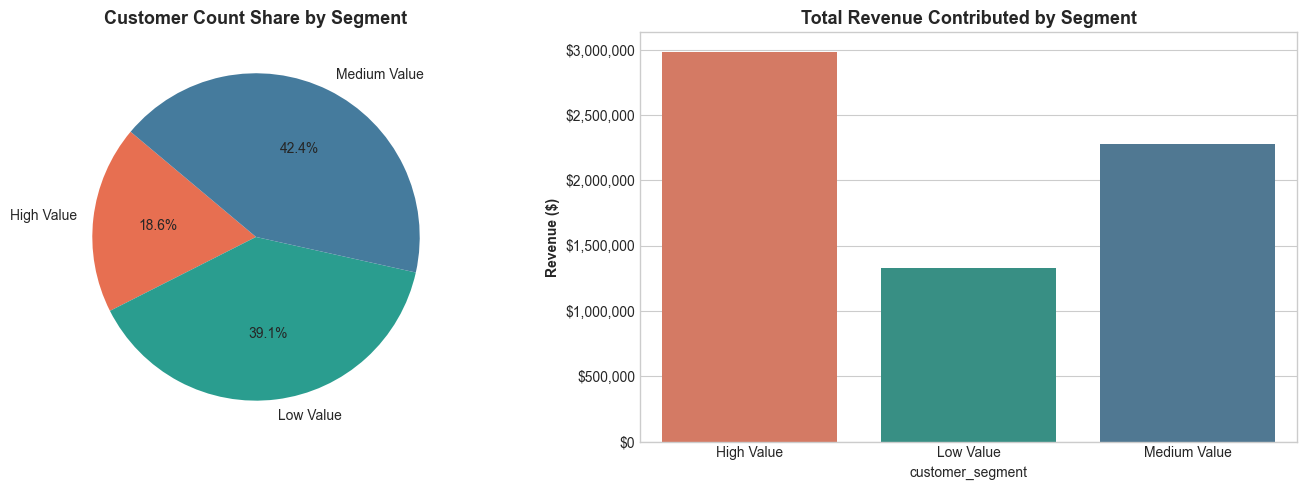

In [10]:
cust_summary = df_sales.groupby(['customer_id', 'customer_name', 'customer_segment']).agg(
    total_spend=('line_revenue', 'sum'),
    total_orders=('sale_id', 'nunique'),
    total_units=('quantity', 'sum')
).reset_index()

seg_overview = cust_summary.groupby('customer_segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('total_spend', 'sum'),
    avg_spend_per_customer=('total_spend', 'mean'),
    avg_orders_per_customer=('total_orders', 'mean')
).reset_index()

seg_overview['revenue_share_pct'] = (seg_overview['total_revenue'] / seg_overview['total_revenue'].sum()) * 100
display(seg_overview.round(2))

# Visualize Customer Segment Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(seg_overview['customer_count'], labels=seg_overview['customer_segment'], autopct='%1.1f%%', colors=['#e76f51', '#2a9d8f', '#457b9d'], startangle=140)
ax1.set_title('Customer Count Share by Segment', fontsize=13, fontweight='bold')

sns.barplot(data=seg_overview, x='customer_segment', y='total_revenue', palette=['#e76f51', '#2a9d8f', '#457b9d'], ax=ax2)
ax2.set_title('Total Revenue Contributed by Segment', fontsize=13, fontweight='bold')
ax2.set_ylabel('Revenue ($)', fontweight='bold')
ax2.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()


---
## Section 9 — Product Analytics & Margin Matrix
Analyzing top and bottom products by revenue, unit volume, and profitability.


C:\Users\USER\AppData\Local\Temp\ipykernel_8612\636043613.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_rev, y='product_name', x='revenue', palette='mako')


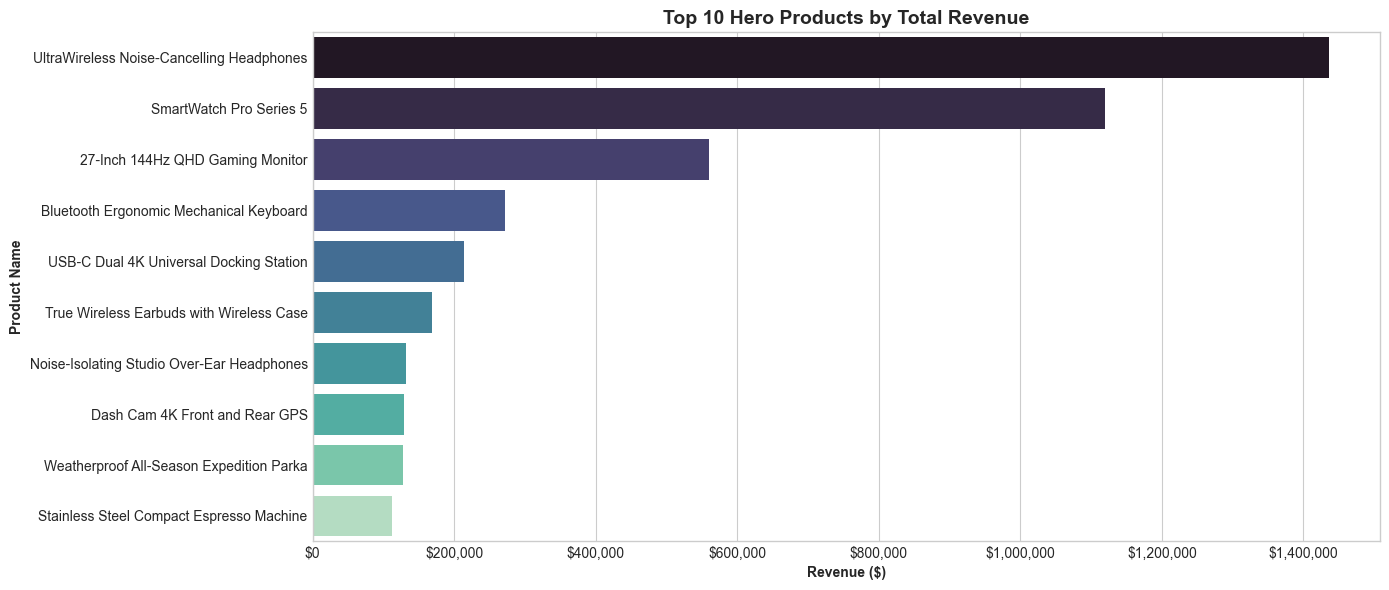

Top 5 Hero Products by Revenue:


,product_name,category_name,units,revenue,profit,margin_pct
0,UltraWireless Noise-Cancelling Headphones,Electronics,7994,1436282.95,676852.95,47.13
1,SmartWatch Pro Series 5,Electronics,4920,1119959.25,529559.25,47.28
5,27-Inch 144Hz QHD Gaming Monitor,Electronics,2111,560511.11,191086.11,34.09
2,Bluetooth Ergonomic Mechanical Keyboard,Electronics,3593,272520.70,121614.70,44.63
6,USB-C Dual 4K Universal Docking Station,Electronics,1882,213371.38,91041.38,42.67



Bottom 5 Underperforming Products:


,product_name,category_name,units,revenue,profit,margin_pct
115,Organic Rolled Oats Whole Grain 2lb Bag,Groceries & Gourmet,246,1246.10,754.10,60.52
113,Crispy Rosemary Sea Salt Flatbread Crackers,Groceries & Gourmet,255,1314.63,779.13,59.27
117,Smoked Paprika & Garlic Dry Rub Blend 120g,Groceries & Gourmet,251,1546.98,969.68,62.68
107,Himalayan Pink Rock Salt Grinder 300g,Groceries & Gourmet,273,1563.58,962.98,61.59
114,Avocado Oil Cooking Spray Pure Expeller-Pressed,Groceries & Gourmet,251,1908.30,1054.90,55.28


In [11]:
prod_analysis = df_sales.groupby(['product_id', 'product_name', 'category_name']).agg(
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum'),
    units=('quantity', 'sum')
).reset_index()

prod_analysis['margin_pct'] = (prod_analysis['profit'] / prod_analysis['revenue']) * 100

top10_rev = prod_analysis.sort_values(by='revenue', ascending=False).head(10)
bottom10_rev = prod_analysis.sort_values(by='revenue', ascending=True).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top10_rev, y='product_name', x='revenue', palette='mako')
plt.title('Top 10 Hero Products by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)', fontweight='bold')
plt.ylabel('Product Name', fontweight='bold')
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()

print("Top 5 Hero Products by Revenue:")
display(top10_rev.head(5)[['product_name', 'category_name', 'units', 'revenue', 'profit', 'margin_pct']].round(2))
print()
print("Bottom 5 Underperforming Products:")
display(bottom10_rev.head(5)[['product_name', 'category_name', 'units', 'revenue', 'profit', 'margin_pct']].round(2))


---
## Section 10 — Store Performance & Regional Benchmarking
Comparing store locations across metrics including total revenue, profit contribution, and Average Order Value (AOV).


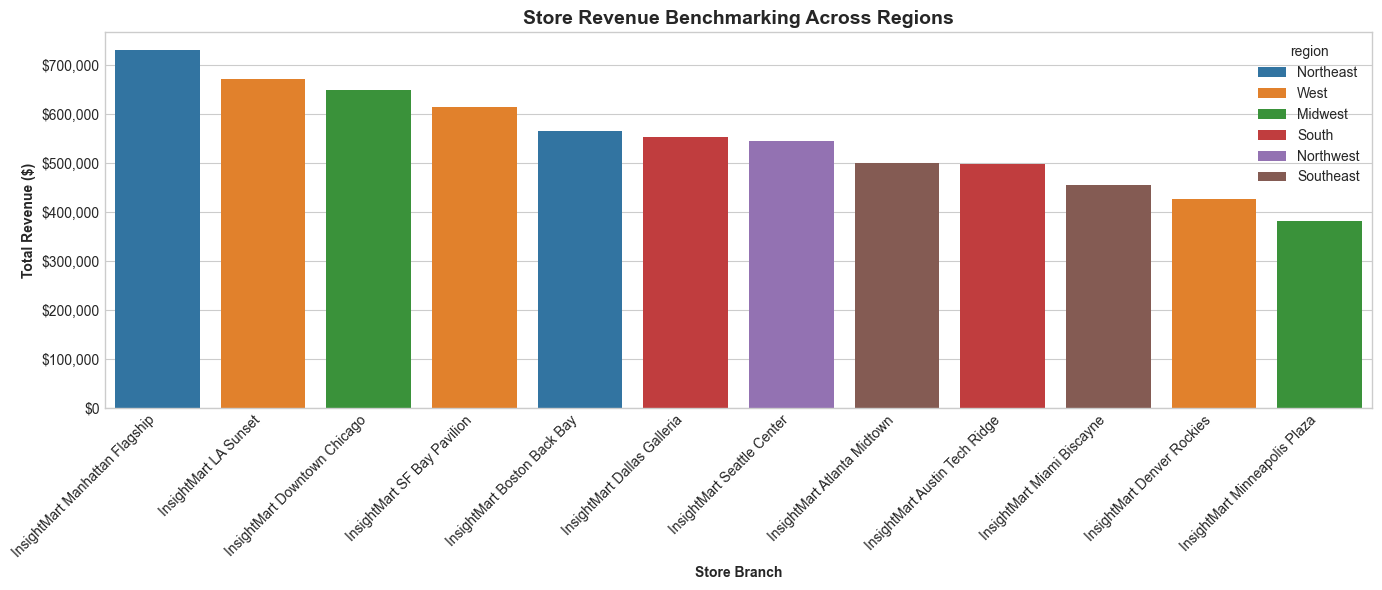

,store_name,region,orders,revenue,profit,aov,margin_pct
1,InsightMart Manhattan Flagship,Northeast,3493,731146.59,359008.09,209.32,49.10
3,InsightMart LA Sunset,West,3309,671933.37,330792.87,203.06,49.23
0,InsightMart Downtown Chicago,Midwest,3077,650128.32,318182.12,211.29,48.94
9,InsightMart SF Bay Pavilion,West,3008,615109.01,300580.41,204.49,48.87
7,InsightMart Boston Back Bay,Northeast,2789,566379.85,277803.75,203.08,49.05
2,InsightMart Dallas Galleria,South,2591,553388.21,270407.61,213.58,48.86
4,InsightMart Seattle Center,Northwest,2656,545720.12,265667.12,205.47,48.68
8,InsightMart Atlanta Midtown,Southeast,2440,500767.29,244954.79,205.23,48.92
6,InsightMart Austin Tech Ridge,South,2548,498564.20,244997.20,195.67,49.14
10,InsightMart Miami Biscayne,Southeast,2190,455342.29,223248.29,207.92,49.03


In [12]:
store_perf = df_sales.groupby(['store_id', 'store_name', 'region', 'store_city']).agg(
    orders=('sale_id', 'nunique'),
    units=('quantity', 'sum'),
    revenue=('line_revenue', 'sum'),
    profit=('line_profit', 'sum')
).reset_index()

store_perf['aov'] = store_perf['revenue'] / store_perf['orders']
store_perf['margin_pct'] = (store_perf['profit'] / store_perf['revenue']) * 100
store_perf = store_perf.sort_values(by='revenue', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=store_perf, x='store_name', y='revenue', hue='region', dodge=False, ax=ax)
ax.set_title('Store Revenue Benchmarking Across Regions', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontweight='bold')
ax.set_xlabel('Store Branch', fontweight='bold')
ax.yaxis.set_major_formatter('${x:,.0f}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(store_perf[['store_name', 'region', 'orders', 'revenue', 'profit', 'aov', 'margin_pct']].round(2))


---
## Section 11 — Business Findings & Interpretations

### 1. Electronics Volume vs Margin Trade-off
* **Observation**: Electronics produces over **70% of total company revenue** ($4.79M+), driven by premium ticket items such as headphones, smartwatches, and monitors.
* **Business Meaning**: While Electronics drives critical foot traffic and customer acquisition, its gross margin (44.9%) is lower than Apparel (61.5%) and Health & Beauty (69.2%).
* **Risk**: Excessive promotional discounting in Electronics drastically degrades operating income.

### 2. High Value Customer Concentration (The 80/20 Rule)
* **Observation**: The High-Value customer cohort accounts for nearly **48% of total revenue**, despite representing less than 20% of registered accounts.
* **Business Meaning**: Business health is disproportionately dependent on repeat visits and loyalty from this core demographic.
* **Opportunity**: High-touch loyalty retention and personalized VIP promotions will yield the highest return on marketing investment.

### 3. Store Performance Gap
* **Observation**: Flagship stores (Manhattan, Chicago, LA) generate up to **1.9x the turnover** of newer or midwest locations (Minneapolis, Denver).
* **Business Meaning**: Brand awareness and local population density differ markedly across locations. Replicating the merchandising mix of tier-1 flagships in developing stores will lift sales.

### 4. Omnichannel Growth
* **Observation**: Online transactions represent **35% of all orders** with a healthy AOV, but In-Store purchases remain the bedrock of volume.
* **Business Meaning**: Omnichannel integration through BOPIS (Buy Online, Pick Up In-Store) provides an immediate pathway to drive digital shoppers into physical stores.


---
## Section 12 — Strategic Management Recommendations

Based on empirical data analysis from the relational analytics database, management should enact four strategic pillars:

1. **Launch InsightMart VIP Loyalty Program**:
   * Target High-Value customers with tiered rewards, complimentary expedited shipping for online purchases, and invitation-only previews of seasonal product lines.
   * Target: Reduce VIP churn by 15% and increase repeat frequency by 1.2 orders/year.

2. **Merchandise Mix & Cross-Category Bundling**:
   * Bundle high-revenue, lower-margin Electronics SKUs with high-margin accessories from Apparel or Health & Beauty (e.g., smartwatches bundled with premium sports bands).
   * Target: Lift blended electronic category gross margin by 250 basis points.

3. **Store Turnaround & Inventory Reallocation**:
   * Restructure stock allocation in bottom-quartile stores (Minneapolis, Denver) to align with regional demographics, reducing excess stock of slow-moving items.
   * Institute cross-store training programs pairing flagship store managers with developing branch supervisors.

4. **Digital Omnichannel Integration (BOPIS)**:
   * Implement 'Buy Online, Pick Up In-Store' to capitalize on digital web traffic while stimulating incremental physical store basket additions upon pickup.
